<a href="https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/github/katelynnlindsey/phonology-chuvash/blob/main/logbook.ipynb

# Acoustic analysis of Chuvash vowels

This notebook documents the steps taken to perform an acoustic analysis of Chuvash vowels, including data acquisition, pre-processing, forced alignment, vowel extraction, and visualization.

## 1. Obtain Acoustic Data

This section outlines the sources for the Chuvash acoustic data used in this project.

### Chuvash-Voice

This dataset is loaded directly from Hugging Face Datasets.

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import re
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Chuvash_voice dataset
chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
# Ensure audio is loaded at a consistent sampling rate
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

print("Chuvash-Voice dataset loaded successfully.")
print(chuvash_voice)

### Common-Voice

Common Voice data requires an API key for programmatic download. The following `curl` commands are provided as an example for manual download.

**Usage Instructions for Common Voice Download:**
1.  **Obtain your API Key:** Go to the Mozilla Common Voice website, log in, and navigate to your account settings or data access page to find your API key.
2.  **Request a Download Token:** Run the first `curl` command below, replacing `YOUR_API_KEY` with your actual API key. This will return a JSON response containing a `downloadToken`.
3.  **Download the Dataset File:** Run the second `curl` command, replacing `DOWNLOAD_TOKEN` with the token obtained in the previous step and `YOUR_API_KEY` again. The Chuvash dataset will be saved as `Common Voice Scripted Speech 24.0 - Chuvash.tar.gz`.

After downloading, you will need to extract the contents of the `.tar.gz` file.

In [ ]:
# curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

# curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

### Common Voice Chuvash TextGrids from Vox Communis

TextGrid files for Common Voice Chuvash are available from the Vox Communis project. These files provide the phonetic segmentation needed for acoustic analysis. You would typically download these separately and place them in a designated `textgrids_commonvoice` directory alongside your audio.

### Phonology class

This section is reserved for any additional acoustic data obtained specifically for a phonology class project. If applicable, describe the source and how it was obtained here.

## 2. Pre-process for Montreal Forced Aligner (MFA)

This step prepares the audio and transcription files for forced alignment. MFA requires audio files in `.wav` format and corresponding transcription files (e.g., `.txt`, `.textgrid`).

### Convert MP3 to WAV

Many datasets might provide audio in `.mp3` format. `new-fave` and `MFA` typically require `.wav` files. The following code snippet demonstrates how to convert `.mp3` files to `.wav` using `ffmpeg`. Ensure `ffmpeg` is installed and accessible in your environment.


In [ ]:
# Example: Convert all .mp3 files in a directory to .wav
import glob
import subprocess

def convert_mp3_to_wav(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    mp3_files = glob.glob(os.path.join(input_dir, "*.mp3"))
    print(f"Found {len(mp3_files)} MP3 files in {input_dir}. Converting to WAV...")

    for mp3_file in mp3_files:
        filename = os.path.basename(mp3_file)
        wav_file = os.path.join(output_dir, filename.replace(".mp3", ".wav"))
        if not os.path.exists(wav_file):
            try:
                # -i: input, -acodec pcm_s16le: PCM 16-bit little-endian, -ar 16000: 16kHz sample rate
                subprocess.run(['ffmpeg', '-i', mp3_file, '-acodec', 'pcm_s16le', '-ar', '16000', wav_file],
                               check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
                print(f"Converted {filename} to WAV.")
            except subprocess.CalledProcessError as e:
                print(f"Error converting {filename}: {e.stderr.decode('utf-8')}")
            except FileNotFoundError:
                print("Error: ffmpeg not found. Please ensure ffmpeg is installed and in your PATH.")
                break
        else:
            print(f"Skipping {filename}: WAV already exists.")

# Example usage:
# mp3_input_directory = "/path/to/your/mp3_audio"
# wav_output_directory = "/path/to/your/wav_audio"
# convert_mp3_to_wav(mp3_input_directory, wav_output_directory)

# Acoustic analysis of Chuvash vowels

1. Obtain acoustic data

Chuvash-Voice

In [ ]:
from datasets import load_dataset, DatasetDict, concatenate_datasets, Audio

chuvash_voice = DatasetDict()
chuvash_voice = load_dataset("alexantonov/chuvash_voice")
chuvash_voice = chuvash_voice.cast_column("audio", Audio(sampling_rate=16000))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

KeyboardInterrupt: 

Common-Voice

Usage Instructions:
1. Replace YOUR_API_KEY with your actual API key in both commands
1.   Run the create download session command to get a download token
2. Replace DOWNLOAD_TOKEN with the token from step 1
3. Run the download command to get the dataset file

In [ ]:
curl -X POST "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download" -H "Authorization: Bearer YOUR_API_KEY" -H "Content-Type: application/json"

In [ ]:
curl -X GET "https://datacollective.mozillafoundation.org/api/datasets/cmj8u3oz40059nxxbu0wyqk1t/download/DOWNLOAD_TOKEN" -H "Authorization: Bearer YOUR_API_KEY" -o "Common Voice Scripted Speech 24.0 - Chuvash.tar.gz"

Common Voice Chuvash textgrids from Vox Communis

Phonology class

2. Pre-process for Montreal Forced Aligner (MFA)

3. Run MFA

4. Pre-process for FAVE vowel extraction

chuvash-manual-recode.py

5. Run new-FAVE

In [ ]:
!pip install new-fave

In [ ]:
chuvash-fave.py

6. Combine extracted vowel data

chuvash-combine.py

7. Visualize results

Import dataframe and filter for vowels

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Define Path to the COMBINED CSV ---
base_corpus_path = "/content"
combined_csv_path = os.path.join(base_corpus_path, "all_chuvash_vowel_points.csv")

# --- Load the combined data ONCE ---
try:
    combined_df = pd.read_csv(combined_csv_path, encoding='utf-8')
    print(f"Successfully loaded combined data with {len(combined_df)} entries.")
    print("Columns available:", combined_df.columns.tolist())

    # Filter for only vowel labels (exclude SIL and any non-vowel markers)
    # Adjust this list if you have other non-vowel labels you want to exclude
    vowels_df = combined_df[~combined_df['label'].isin(['SIL', '<eps>', '#'])].copy()
    print(f"Filtered for vowels: {len(vowels_df)} entries remaining.")

except FileNotFoundError:
    print(f"Error: Combined CSV file not found at '{combined_csv_path}'. Please run 'combine_fave_points_data.py' first.")
    # Exit or handle the error appropriately if running as a script
    # For a notebook, you might just display an error and let the user fix it.
except Exception as e:
    print(f"An error occurred while loading or preparing data: {e}")
    # Handle error
    vowels_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors if loading fails

Successfully loaded combined data with 53881 entries.
Columns available: ['F1', 'F2', 'F3', 'B1', 'B2', 'B3', 'max_formant', 'smooth_error', 'time', 'rel_time', 'prop_time', 'id', 'label', 'file_name', 'group', 'speaker_num', 'point_heuristic', 'f0', 'intensity', 'optimized', 'word', 'dur', 'pre_word', 'fol_word', 'pre_seg', 'fol_seg', 'abs_pre_seg', 'abs_fol_seg', 'context', 'phon_stress', 'sidx', 'sN', 'syl_pos', 'syl_open_closed', 'corpus']
Filtered for vowels: 46286 entries remaining.


Total data = 865384 --> 752485

Filter dataframe by removing outliers

In [82]:
import pandas as pd
import numpy as np
import re # Import the re module for regular expressions


print(f"\nOriginal DataFrame shape: {vowels_df.shape}")

# Ensure 'word' and 'label', and 'phon_stress' columns exist before proceeding
if 'word' not in vowels_df.columns:
    raise KeyError("The 'word' column is missing from your DataFrame. It's required for Russian character filtering.")
if 'label' not in vowels_df.columns:
    raise KeyError("The 'label' column is missing from your DataFrame. It's required for grouped outlier filtering.")
if 'phon_stress' not in vowels_df.columns:
    raise KeyError("The 'phon_stress' column is missing from your DataFrame. It's required for grouped outlier filtering by stress.")


# --- Step 1: Filter out vowels in words containing specified "Russian" character representations ---

# Define the Latin letter sequences that indicate Russian influence (case-insensitive)
# Sorted by length descending to ensure multi-character sequences like 'ZH' are matched before 'Z'.
russian_latin_sequences = ['ZH','ts','B','G','D','F','Z','O','Б','Г','Д','О','Ж','Ц','Ф','З','Ë','ё','Ё']
russian_latin_sequences_sorted = sorted(russian_latin_sequences, key=len, reverse=True)

initial_rows = vowels_df.shape[0]

# Create a regex pattern from the sorted sequences, escaping any special characters
# and joining them with '|' for OR logic.
russian_pattern = '|'.join([re.escape(s) for s in russian_latin_sequences_sorted])

# Create a boolean mask: True if the word contains any of the specified sequences
# Convert the 'word' to uppercase for case-insensitive matching.
mask_russian_words = vowels_df['word'].str.upper().str.contains(russian_pattern, na=False)

# Filter the DataFrame to keep only rows where the word does NOT contain these sequences
df_no_russian = vowels_df[~mask_russian_words].copy() # .copy() to avoid SettingWithCopyWarning

russian_rows_removed = initial_rows - df_no_russian.shape[0]
print(f"\n{russian_rows_removed} rows removed due to specified Russian orthography in 'word' column.")
print(f"DataFrame shape after Russian sequence filtering: {df_no_russian.shape}")


# --- Step 2: Filter outliers using the IQR method ---

outlier_columns = ['F1', 'F2', 'dur', 'intensity', 'f0']

filtered_df = df_no_russian.copy() # Start with the DataFrame that has no Russian words

# This check is now less critical as transform maintains columns, but good for early exit
if filtered_df.empty:
    print("DataFrame became empty after Russian word filtering. No outlier filtering performed.")
else:
    for col in outlier_columns:
        print(f"\nFiltering outliers for column: {col}")

        # Ensure the column to filter is actually in the DataFrame
        if col not in filtered_df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping outlier filter for this column.")
            continue # Skip to the next column

        # Calculate group-wise Q1, Q3, and IQR using .transform()
        # IMPORTANT CHANGE HERE: Group by both 'label' and 'phon_stress'
        Q1 = filtered_df.groupby(['label', 'phon_stress'])[col].transform(lambda x: x.quantile(0.25))
        Q3 = filtered_df.groupby(['label', 'phon_stress'])[col].transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Apply the filter based on these group-specific bounds
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)].copy()

# Calculate removed rows after all filters are applied
outlier_rows_removed = df_no_russian.shape[0] - filtered_df.shape[0]
print(f"\n{outlier_rows_removed} rows were identified as outliers and removed by IQR method.")
print(f"Final Filtered DataFrame shape: {filtered_df.shape}")
total_rows_removed = vowels_df.shape[0] - filtered_df.shape[0]
print(f"Total {total_rows_removed} rows removed from the original DataFrame.")


Original DataFrame shape: (46286, 35)

2603 rows removed due to specified Russian orthography in 'word' column.
DataFrame shape after Russian sequence filtering: (43683, 35)

Filtering outliers for column: F1

Filtering outliers for column: F2

Filtering outliers for column: dur

Filtering outliers for column: intensity

Filtering outliers for column: f0

8111 rows were identified as outliers and removed by IQR method.
Final Filtered DataFrame shape: (35572, 35)
Total 10714 rows removed from the original DataFrame.


In [83]:
filtered_df.head(10)

,F1,F2,F3,B1,B2,B3,max_formant,smooth_error,time,rel_time,...,fol_seg,abs_pre_seg,abs_fol_seg,context,phon_stress,sidx,sN,syl_pos,syl_open_closed,corpus
0,442.057181,1978.295406,2825.277903,3.471660,3.407980,3.953726,6948.717949,0.000688,0.391375,0.035,...,N,M,N,internal,1.0,1.0,1.0,initial,closed,mfa
1,684.501863,1532.768322,2840.683902,3.719236,3.522756,3.598707,5692.307692,0.000222,0.624375,0.041,...,L,K,L,internal,1.0,1.0,2.0,initial,open,mfa
2,607.297155,1386.809083,3181.692295,3.313887,3.336523,3.649938,6589.743590,0.000082,0.801375,0.035,...,N,L,N,internal,0.0,2.0,2.0,final,closed,mfa
7,355.248772,758.036808,1349.725026,3.585527,3.640809,4.660258,4256.410256,0.000144,1.206375,0.025,...,R,K,R,internal,0.0,1.0,4.0,initial,open,mfa
8,698.459145,1358.453260,2236.099617,3.450163,3.574950,4.104891,6589.743590,0.000151,1.322375,0.037,...,K,R,K,internal,0.0,2.0,4.0,med,open,mfa
9,643.467077,1723.971491,2979.071511,3.568701,3.630415,3.760700,6769.230769,0.000014,1.467375,0.027,...,N,K,N,internal,0.0,3.0,4.0,med,open,mfa
10,865.629426,1726.514580,3034.067377,3.623731,3.437200,3.772085,6769.230769,0.001088,1.624375,0.061,...,#,N,AA0 [sidx=1/sN=4/pos=initial/oc=closed],final,1.0,4.0,4.0,final,open,mfa
12,436.652929,2301.126089,2970.767548,3.135125,3.479263,3.113258,6410.256410,0.000107,2.381375,0.035,...,#,P,T,final,1.0,4.0,4.0,final,open,mfa
13,719.821159,1708.041856,2858.615765,3.171076,3.633033,3.180225,7487.179487,0.000029,2.531375,0.035,...,N,T,N,internal,0.0,1.0,2.0,initial,open,mfa
14,839.432595,1688.908633,2940.400695,3.445740,3.766603,4.049996,7307.692308,0.000132,2.692375,0.037,...,HH,N,HH,internal,1.0,2.0,2.0,final,closed,mfa


Plotting 6387 stressed medial vowels.
Unique stressed medial vowels found: ['AA' 'EH' 'AH' 'EY' 'IY' 'UX' 'UW' 'IX']


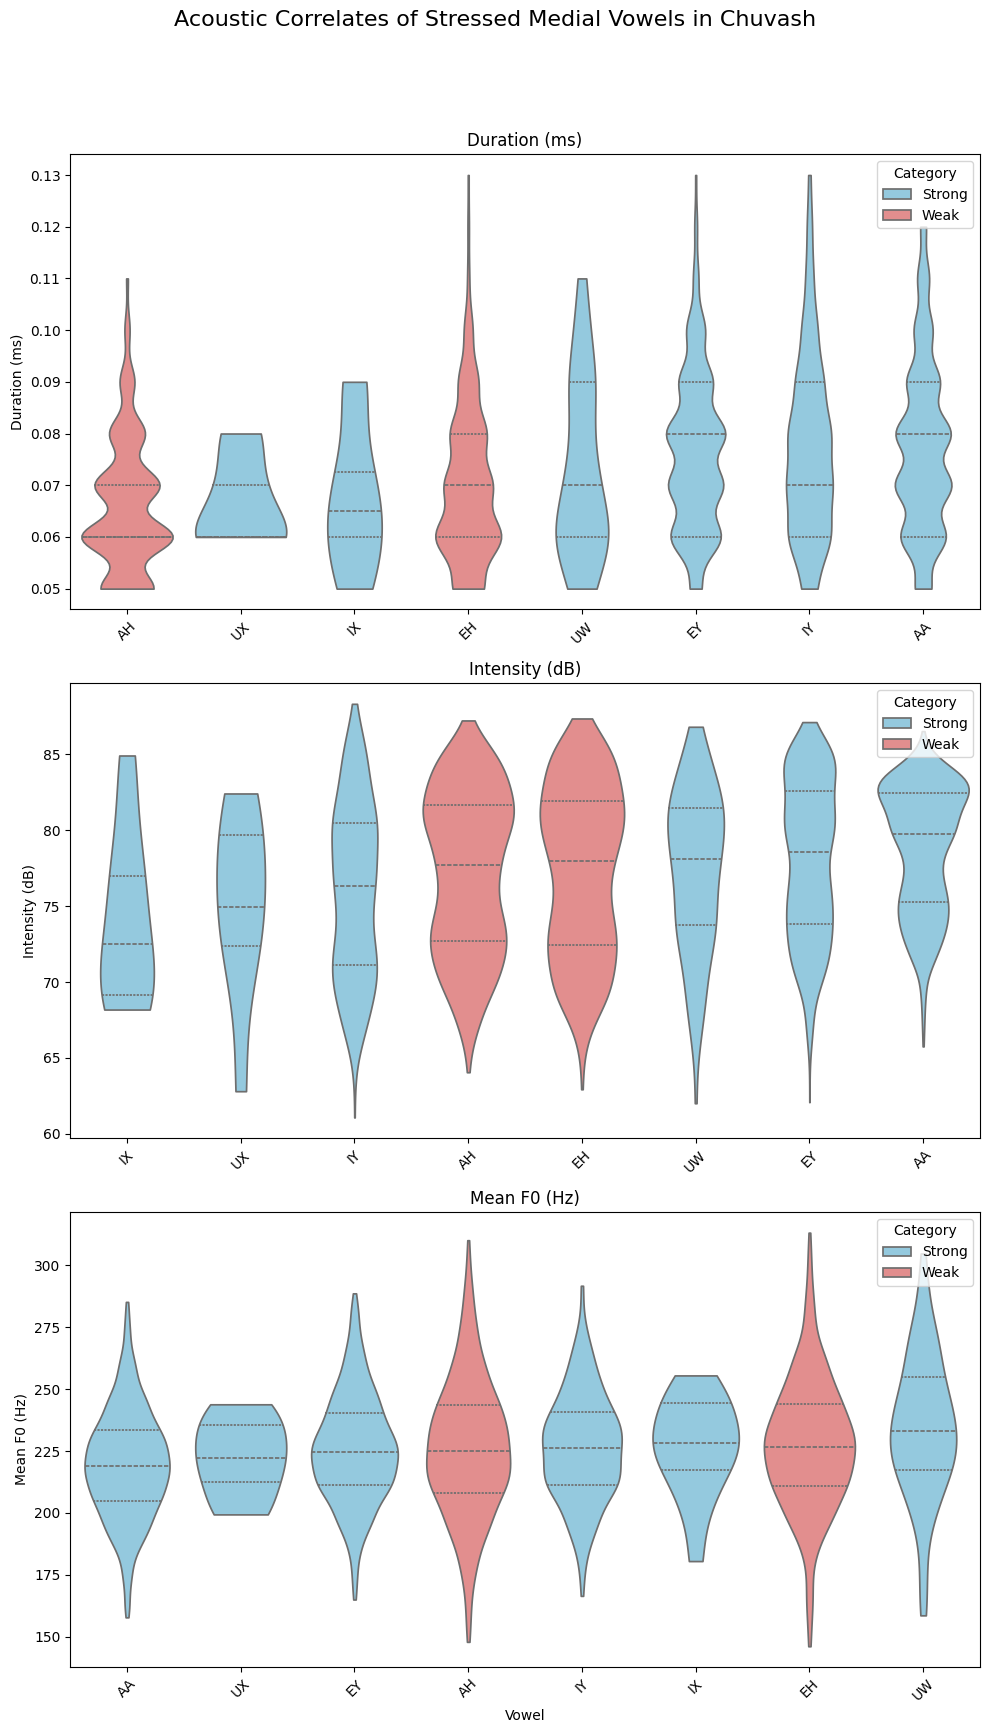

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# from matplotlib.font_manager import FontProperties # Uncomment and set up if you need specific IPA fonts

# --- 0. Set up IPA font (optional, see previous notes) ---
# If your 'label' column already uses a font that renders well, you might not need this.
# Otherwise, consider installing a font like Charis SIL or Doulos SIL and configuring matplotlib.
# font_path = '/path/to/your/CharisSILR.ttf'
# prop = FontProperties(fname=font_path, size=12)
# plt.rcParams['font.family'] = prop.get_name()
# plt.rcParams['font.sans-serif'] = prop.get_name()

# --- 1. Prepare Your Data (using your 'filtered_df') ---
# Assuming 'filtered_df' is already loaded with your raw data.

# --- IMPORTANT: CONFIRM THESE COLUMN NAMES ARE EXACT IN YOUR DataFrame ---
DURATION_COL = 'dur'
INTENSITY_COL = 'intensity' # As clarified: 'intensity'
F0_COL = 'f0'               # As clarified: 'f0'
LABEL_COL = 'label'         # Contains 'AA1', 'EH0', etc.
SYL_POS_COL = 'syl_pos'     # Contains 'initial', 'med', 'final'
PHON_STRESS_COL = 'phon_stress' # Contains 1.0, 0.0, NaN

# Make a copy to add new columns, avoiding SettingWithCopyWarning if filtered_df is a slice
plot_data_prep = filtered_df.copy()

# 1.1 Correctly extract base vowel and stress type from 'label' and 'phon_stress'
#    'vowel' should be just the ARPAbet symbol (e.g., 'AA', 'EH'), stripping the stress digit
plot_data_prep['vowel_base'] = plot_data_prep[LABEL_COL]

#    'stress_type' should compare the float 'phon_stress' to the float 1.0
#    Handle NaN values (e.g., for SIL) by treating them as unstressed or filtering them out later
plot_data_prep['stress_type'] = plot_data_prep[PHON_STRESS_COL].apply(
    lambda x: 'Stressed' if pd.notna(x) and x == 1.0 else 'Unstressed'
)

# 1.2 Define your strong/weak vowel categories using the *base* vowel names
# Based on your input: "AH" and "EH" are weak. All others are strong.
strong_vowels = ["IY", "IX", "UX", "UW", "EY", "AA"]
weak_vowels = ["AH", "EH"]

plot_data_prep['vowel_category'] = plot_data_prep['vowel_base'].apply(lambda x: 'Strong' if x in strong_vowels else 'Weak')

# --- 2. Filter the Data for Stressed Medial Vowels ---
# This filter is based on your current request: "stressed" (using your phonological stress)
# and "medial" position.
plot_df = plot_data_prep[
    (plot_data_prep[SYL_POS_COL] == 'med') &
    (plot_data_prep['stress_type'] == 'Unstressed') # Filter for 'Stressed' here
].copy() # Ensure this is a fresh copy for plotting

# --- CRITICAL CHECK: After filtering, check if plot_df is empty ---
if plot_df.empty:
    print("Warning: The filtered DataFrame for 'stressed medial' vowels is empty.")
    print("This means there are no vowels matching the criteria ('syl_pos' == 'med' and 'phon_stress' == 1.0).")
    print("Please verify your data or adjust filtering criteria if this is unexpected.")
    # You might want to remove 'med' filter for debugging, or try filtering for 'Unstressed' instead.
else:
    print(f"Plotting {len(plot_df)} stressed medial vowels.")
    print("Unique stressed medial vowels found:", plot_df['vowel_base'].unique())


# --- 3. Create the Plots ---
fig, axes = plt.subplots(3, 1, figsize=(10, 18), sharex=False) # 3 rows, 1 column; taller figure
# Adjusted suptitle to reflect the filtering for 'Stressed Medial' vowels
fig.suptitle(f'Acoustic Correlates of Stressed Medial Vowels in Chuvash', fontsize=16, y=0.99)

# Define metrics and their labels for plotting
metrics = [DURATION_COL, INTENSITY_COL, F0_COL]
titles = ['Duration (ms)', 'Intensity (dB)', 'Mean F0 (Hz)'] # Labels for y-axis
# Custom palette for 'Strong' vs 'Weak' categories, as requested
category_palette = {'Strong': 'skyblue', 'Weak': 'lightcoral'}


for i, metric in enumerate(metrics):
    # Calculate mean for ordering the x-axis for this specific metric
    # Order by mean of *vowel_base* for the current metric
    mean_order = plot_df.groupby('vowel_base')[metric].mean().sort_values().index

    sns.violinplot(x='vowel_base', y=metric, data=plot_df, order=mean_order,
                   hue='vowel_category', palette=category_palette, ax=axes[i],
                   inner='quartile', # Shows median and quartiles inside the violin
                   cut=0) # Limits the violin to the range of the data.

    axes[i].set_title(titles[i])
    axes[i].set_ylabel(titles[i])
    axes[i].set_xlabel('Vowel')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Category', loc='upper right', bbox_to_anchor=(1.0, 1.0))

    # Ensure x-axis tick labels are always visible on all plots
    if i < len(metrics) - 1:
        axes[i].set_xlabel('') # Keep x-label empty for top plots for cleaner look
        axes[i].tick_params(axis='x', labelbottom=True) # Ensure tick labels are visible
    else:
        axes[i].set_xlabel('Vowel') # Set x-label for the bottom plot
        axes[i].tick_params(axis='x', labelbottom=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle and legends
plt.show()

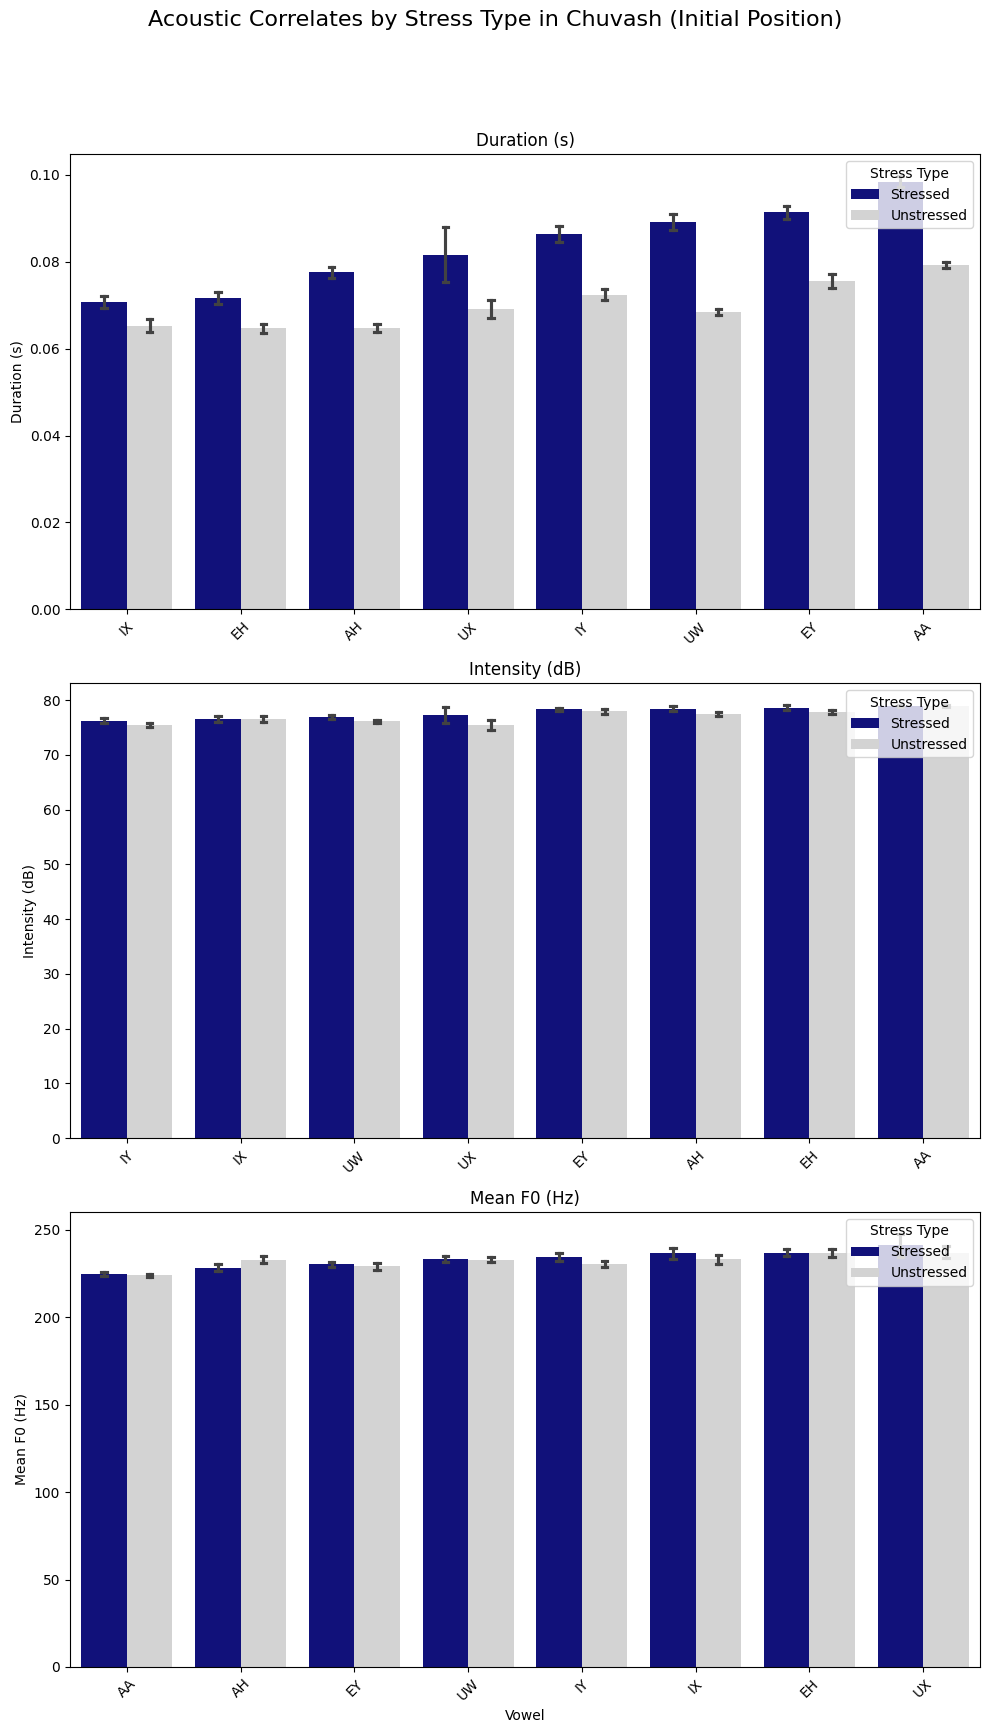

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 0. Set up IPA font (optional, see previous notes) ---
# If your 'label' column already uses a font that renders well, you might not need this.
# Otherwise, consider installing a font like Charis SIL or Doulos SIL and configuring matplotlib.
# font_path = '/path/to/your/CharisSILR.ttf'
# prop = FontProperties(fname=font_path, size=12)
# plt.rcParams['font.family'] = prop.get_name()
# plt.rcParams['font.sans-serif'] = prop.get_name()

# --- 1. Prepare Your Data (using your 'filtered_df') ---
# Assuming 'filtered_df' is already loaded with your raw data.

# --- IMPORTANT: CONFIRM THESE COLUMN NAMES ARE EXACT IN YOUR DataFrame ---
DURATION_COL = 'dur'
INTENSITY_COL = 'intensity'
F0_COL = 'f0'
LABEL_COL = 'label' # This column should contain values like 'IY1', 'AH0', etc.
SYL_POS_COL = 'syl_pos'
STRESS = 'phon_stress'

# 1.1 Extract base vowel and stress type from 'label'
# This assumes 'label' is like 'IY1', 'AH0', etc., where the last character is '1' for stressed, '0' for unstressed.
# Make sure to work on a copy to avoid SettingWithCopyWarning if filtered_df is a slice
plot_data_prep = filtered_df.copy()
plot_data_prep['vowel'] = plot_data_prep[LABEL_COL]
plot_data_prep['stress_type'] = plot_data_prep[PHON_STRESS_COL].apply(
    lambda x: 'Stressed' if pd.notna(x) and x == 1.0 else 'Unstressed'
)

# 1.2 Define your strong/weak vowel categories
# Based on your input: "AH" and "EH" are weak. All others are strong.
strong_vowels = ["IY", "IX", "UX", "UW", "EY", "AA"]
weak_vowels = ["AH", "EH"]

plot_data_prep['vowel_category'] = plot_data_prep['vowel'].apply(lambda x: 'Strong' if x in strong_vowels else 'Weak')

# 1.3 Create a combined category for coloring, if desired, or rely on distinct stress_type colors
# For direct comparison per vowel, `hue='stress_type'` is most direct.
# The `vowel_category` can be visually implied by the ordering or discussed in text.

# --- 2. Filter the Data for a SPECIFIC SYLLABLE POSITION ---
# We need to control for syllable position, so let's pick 'med' (medial) for this analysis.
SELECTED_SYL_POS = 'initial'

plot_df = plot_data_prep[
    (plot_data_prep[SYL_POS_COL] == SELECTED_SYL_POS)
].copy()

# --- 3. Create the Plots ---
fig, axes = plt.subplots(3, 1, figsize=(10, 18), sharex=False) # 3 rows, 1 column; taller figure
fig.suptitle(f'Acoustic Correlates by Stress Type in Chuvash ({SELECTED_SYL_POS.capitalize()} Position)', fontsize=16, y=0.99)

# Define metrics and their labels for plotting
metrics = [DURATION_COL, INTENSITY_COL, F0_COL]
titles = ['Duration (s)', 'Intensity (dB)', 'Mean F0 (Hz)'] # Labels for y-axis

# Custom palette for 'Stressed' vs 'Unstressed'
# You can customize these colors further if you want to subtly indicate Strong/Weak within them.
# For simplicity, we'll just use a standard 'Stressed' vs 'Unstressed' palette here.
stress_palette = {'Stressed': 'darkblue', 'Unstressed': 'lightgray'}

for i, metric in enumerate(metrics):
    # Calculate mean for ordering the x-axis for this specific metric
    # Order by mean of *Stressed* values to see the effect of stress relative to a baseline
    mean_stressed_order = plot_df[plot_df['stress_type'] == 'Stressed'].groupby('vowel')[metric].mean().sort_values().index

    # Handle cases where some vowels might not have 'Stressed' data in the filtered set
    if len(mean_stressed_order) < len(plot_df['vowel'].unique()):
        all_vowels = plot_df['vowel'].unique()
        # Add any missing vowels to the end, ordered alphabetically
        remaining_vowels = sorted([v for v in all_vowels if v not in mean_stressed_order])
        vowel_order = list(mean_stressed_order) + remaining_vowels
    else:
        vowel_order = list(mean_stressed_order)

    sns.barplot(x='vowel', y=metric, data=plot_df, order=vowel_order,
                hue='stress_type', palette=stress_palette, ax=axes[i],
                capsize=0.1, errorbar='ci') # capsize adds caps to error bars, errorbar shows confidence interval

    axes[i].set_title(titles[i])
    axes[i].set_ylabel(titles[i])
    axes[i].set_xlabel('Vowel')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Stress Type', loc='upper right', bbox_to_anchor=(1.0, 1.0))

    # Ensure x-axis tick labels are always visible on all plots
    if i < len(metrics) - 1:
        axes[i].set_xlabel('') # Keep x-label empty for top plots for cleaner look
        axes[i].tick_params(axis='x', labelbottom=True) # Ensure tick labels are visible
    else:
        axes[i].set_xlabel('Vowel') # Set x-label for the bottom plot
        axes[i].tick_params(axis='x', labelbottom=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [88]:
import pandas as pd

# Assuming plot_data_prep is the DataFrame with 'vowel', 'stress_type', 'vowel_category', 'syl_pos' columns
# from the previous code execution.

# Define your strong/weak vowel categories again to be safe
strong_vowels = ["IY", "IX", "UW", "EY", "AA"]
weak_vowels = ["AH", "EH", "UX"]

# Re-create vowel_category for this check
plot_data_prep['vowel_category'] = plot_data_prep['vowel'].apply(lambda x: 'Strong' if x in strong_vowels else 'Weak')


# Filter for stressed weak vowels in medial position
stressed_weak_medial_vowels = plot_data_prep[
    (plot_data_prep['vowel_category'] == 'Weak') &
    (plot_data_prep['stress_type'] == 'Stressed') &
    (plot_data_prep['syl_pos'] == 'med')
]

print(f"Count of Stressed 'Weak' vowels in Medial position: {len(stressed_weak_medial_vowels)}")
if not stressed_weak_medial_vowels.empty:
    print("\nThese are the specific 'Weak' vowels observed as Stressed in Medial position:")
    print(stressed_weak_medial_vowels['vowel'].value_counts())
    print("\nFirst 5 rows of this data subset:")
    print(stressed_weak_medial_vowels.head())
else:
    print("No stressed 'Weak' vowels found in Medial position in the data.")

Count of Stressed 'Weak' vowels in Medial position: 6

These are the specific 'Weak' vowels observed as Stressed in Medial position:
vowel
UX    6
Name: count, dtype: int64

First 5 rows of this data subset:
               F1           F2           F3        B1        B2        B3  \
5387   388.592654  1701.509706  2246.496755  2.281332  3.660689  4.307183   
7310   412.917586  1856.780447  2616.535366  2.639736  3.835600  3.340092   
8215   437.794789  1707.000332  2727.993266  2.922035  4.023816  2.987781   
32713  426.518855  2312.509066  2929.732106  3.193463  3.498146  2.802846   
36694  347.775462  2213.911087  2748.119585  2.898801  3.026221  3.366416   

       max_formant  smooth_error      time  rel_time  ...   context  \
5387   4076.923077      0.000266  3.581375     0.035  ...  internal   
7310   5512.820513      0.000077  1.796375     0.045  ...  internal   
8215   6769.230769      0.000101  1.474375     0.041  ...  internal   
32713  6769.230769      0.000464  5.134375   

In [89]:
import pandas as pd

# Assuming plot_data_prep_for_check is the DataFrame with 'vowel', 'stress_type', 'vowel_category', 'syl_pos'
# and the 'word' column (which should be present in your original filtered_df).
# If 'word' is not a column, you'll need to adjust this.

# Define your strong/weak vowel categories again to be safe
strong_vowels = ["IY", "IX", "UW", "EY", "AA"]
weak_vowels = ["AH", "EH", "UX"]

# Re-create vowel_category for this check
plot_data_prep['vowel_category'] = plot_data_prep['vowel'].apply(lambda x: 'Strong' if x in strong_vowels else 'Weak')


# Filter for stressed weak vowels in medial position
problematic_data = plot_data_prep[
    (plot_data_prep['vowel_category'] == 'Weak') &
    (plot_data_prep['stress_type'] == 'Stressed') &
    (plot_data_prep['syl_pos'] == 'med')
]

# --- Extract unique words ---
if 'word' in problematic_data.columns:
    unique_problematic_words = problematic_data['word'].unique().tolist()
    print(f"Number of unique problematic words: {len(unique_problematic_words)}")
    print("\nList of unique problematic words:")
    # Print in a more readable format, perhaps a few per line
    for i, word in enumerate(unique_problematic_words):
        print(f"'{word}'", end=', ' if i < len(unique_problematic_words) - 1 else '')
        if (i + 1) % 5 == 0: # Print 5 words per line
            print()
    print("\n")
else:
    print("Error: 'word' column not found in the problematic_data DataFrame.")
    print("Please ensure your original 'filtered_df' contains a 'word' column or adjust the column name.")

Number of unique problematic words: 6

List of unique problematic words:
'K.IYL.'EHSH.UXL.EH', 'HH.'EHR.UXL.EHHH.EH', 'HH.'EHR.UXL.EHHH', 'K.'EHT.UXɕ.EH', 'SH.UXTL.'EHP.UXTL.EH', 
'ɕ.EHNT.'EYR.UXɕ.EH'



Plot F1 x F2

/tmp/ipython-input-42089026.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap


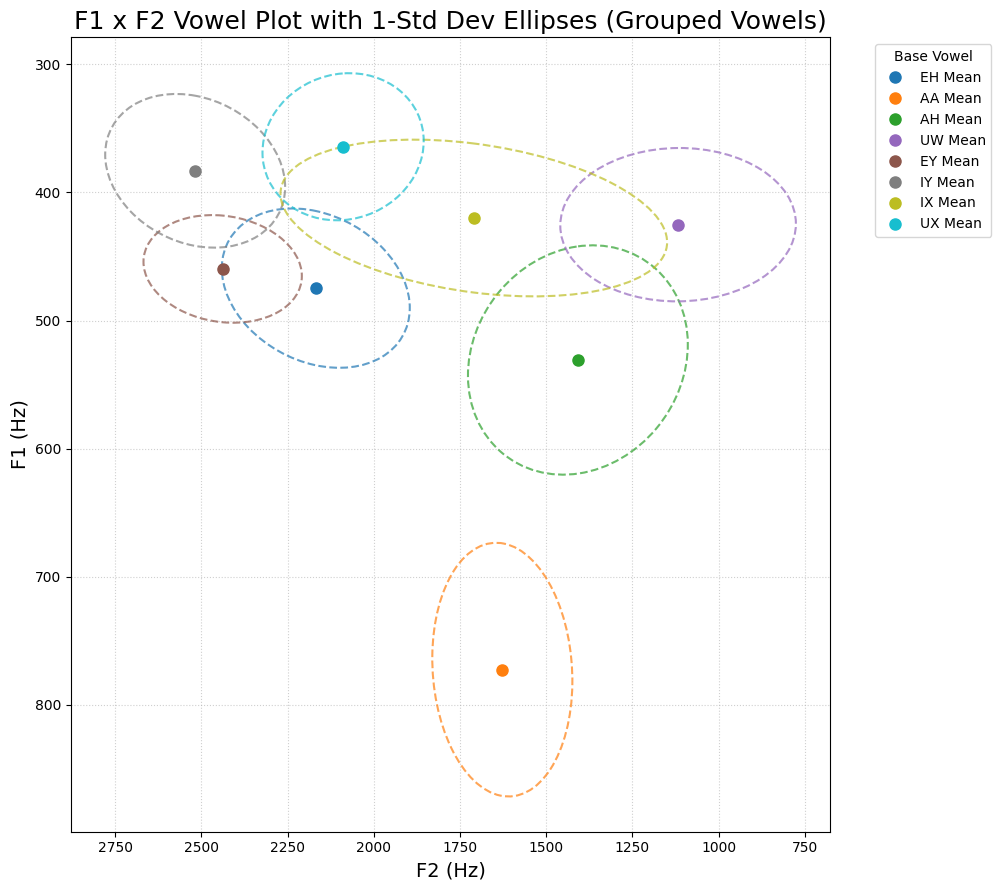

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm # For color mapping
import re # Regular expression library for stripping numbers

# --- Start of placeholder for filtered_df if running standalone ---
# In your Google Colab notebook, 'filtered_df' should already exist from the previous steps.
# This block is just for demonstration if you run this code snippet independently.
if 'filtered_df' not in locals():
    print("Warning: 'filtered_df' not found. Creating dummy data for demonstration.")
    np.random.seed(42) # for reproducibility
    data = {
        'F1': np.random.normal(500, 50, 50).tolist() + np.random.normal(520, 45, 50).tolist() + # AA1, AA0
              np.random.normal(700, 60, 50).tolist() + np.random.normal(710, 55, 50).tolist() + # IY1, IY0
              np.random.normal(300, 40, 50).tolist() + np.random.normal(310, 35, 50).tolist() + # UW1, UW0
              np.random.normal(450, 45, 50).tolist() + np.random.normal(460, 40, 50).tolist(),  # AE1, AE0
        'F2': np.random.normal(1500, 100, 50).tolist() + np.random.normal(1550, 90, 50).tolist() +
              np.random.normal(1200, 80, 50).tolist() + np.random.normal(1250, 75, 50).tolist() +
              np.random.normal(2000, 120, 50).tolist() + np.random.normal(2050, 110, 50).tolist() +
              np.random.normal(1800, 90, 50).tolist() + np.random.normal(1850, 85, 50).tolist(),
        'label': ['AA1']*50 + ['AA0']*50 + ['IY1']*50 + ['IY0']*50 +
                 ['UW1']*50 + ['UW0']*50 + ['AE1']*50 + ['AE0']*50,
        'dur': np.random.rand(400), 'intensity': np.random.rand(400), 'f0': np.random.rand(400)
    }
    filtered_df = pd.DataFrame(data)
    filtered_df['F1'] = pd.to_numeric(filtered_df['F1'])
    filtered_df['F2'] = pd.to_numeric(filtered_df['F2'])
# --- End of placeholder ---


# --- New step: Create 'base_vowel' column ---
# This uses a regular expression to remove any trailing digits from the 'label'
filtered_df['base_vowel'] = filtered_df['label'].apply(lambda x: re.sub(r'[0-9]', '', x))

# Group by 'base_vowel' to calculate mean and covariance for F1 and F2
vowel_means = filtered_df.groupby('base_vowel')[['F1', 'F2']].mean()

# Dictionary to store covariance matrices for each base vowel
vowel_covariances = {}
for base_vowel_label in filtered_df['base_vowel'].unique():
    subset = filtered_df[filtered_df['base_vowel'] == base_vowel_label][['F1', 'F2']]
    # Ensure there's enough data for covariance calculation (at least 2 points)
    if len(subset) > 1:
        vowel_covariances[base_vowel_label] = np.cov(subset['F1'], subset['F2'])
    else:
        print(f"Warning: Not enough data for '{base_vowel_label}' to calculate covariance matrix. Skipping ellipse.")
        vowel_covariances[base_vowel_label] = None # Store None to skip plotting ellipse

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 9))

# Get a color map for distinct colors for each base vowel
base_labels = filtered_df['base_vowel'].unique()
colors = cm.get_cmap('tab10', len(base_labels)) # 'tab10' is a good categorical colormap

# Plot each base vowel's mean and 1-standard deviation ellipse
for i, base_vowel_label in enumerate(base_labels):
    mean_f1 = vowel_means.loc[base_vowel_label, 'F1']
    mean_f2 = vowel_means.loc[base_vowel_label, 'F2']
    color = colors(i)

    # Plot the mean point
    ax.plot(mean_f2, mean_f1, 'o', color=color, markersize=8, label=f'{base_vowel_label} Mean', zorder=5)

    # Plot ellipse only if covariance matrix was successfully calculated
    cov_matrix = vowel_covariances.get(base_vowel_label)
    if cov_matrix is not None:
        # Calculate ellipse parameters from the covariance matrix
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues in descending order and get corresponding eigenvectors
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        # The angle of the ellipse is the angle of the eigenvector corresponding to the largest eigenvalue
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))

        # For a "1 standard deviation" ellipse, the half-axes are proportional to sqrt(eigenvalues).
        width, height = 2 * np.sqrt(eigenvalues)

        # Create and add the ellipse patch
        ellipse = Ellipse((mean_f2, mean_f1), width=width, height=height,
                          angle=angle, facecolor='none', edgecolor=color,
                          linestyle='--', linewidth=1.5, alpha=0.7, zorder=3)
        ax.add_patch(ellipse)
    else:
        print(f"Skipping ellipse for '{base_vowel_label}' due to insufficient data for covariance calculation.")


# Customize the plot
ax.set_title('F1 x F2 Vowel Plot with 1-Std Dev Ellipses (Grouped Vowels)', fontsize=18)
ax.set_xlabel('F2 (Hz)', fontsize=14)
ax.set_ylabel('F1 (Hz)', fontsize=14)
ax.invert_yaxis() # F1 is traditionally inverted in phonetic plots
ax.invert_xaxis() # F2 is traditionally inverted in phonetic plots
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(title='Base Vowel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Place legend outside
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

/tmp/ipython-input-414387687.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=filtered_df, x='label', y='F2', inner='quartile', palette='viridis')


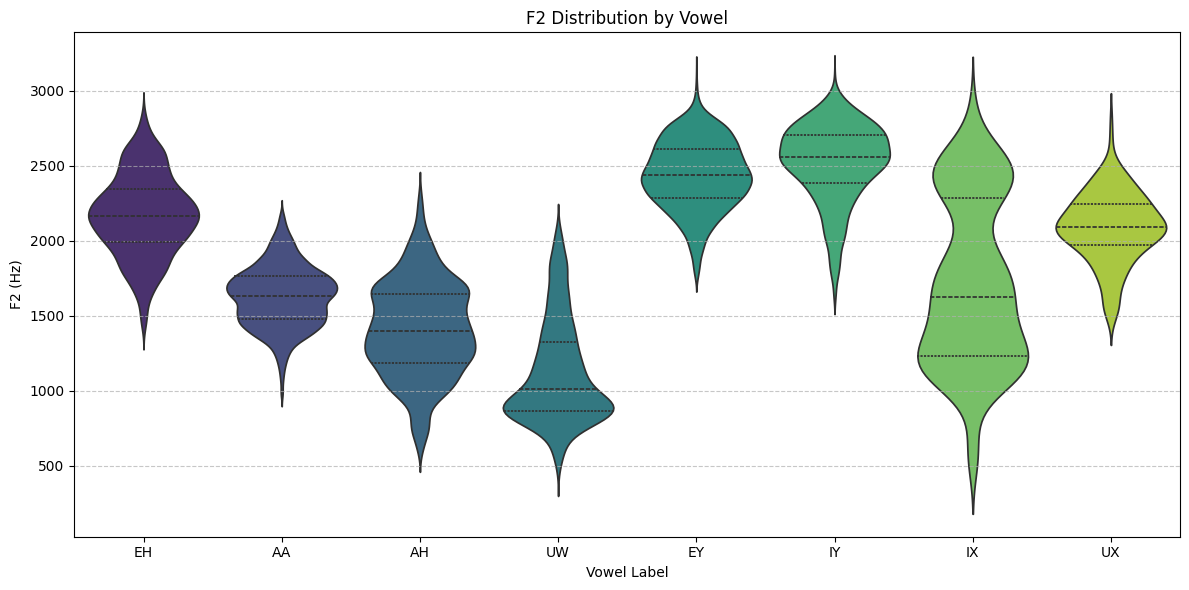

In [94]:
# Cell 2: F2 Distribution by Vowel
if not filtered_df.empty:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=filtered_df, x='label', y='F2', inner='quartile', palette='viridis')
    plt.title('F2 Distribution by Vowel')
    plt.xlabel('Vowel Label')
    plt.ylabel('F2 (Hz)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No vowel data available for F1 distribution plot.")

Total vowel tokens: 35572
Tokens after palatal consonants: 4993
Tokens after non-palatal consonants: 30579
--------------------------------------------------


/tmp/ipython-input-3756041146.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors1 = cm.get_cmap('tab10', len(base_labels_sorted))


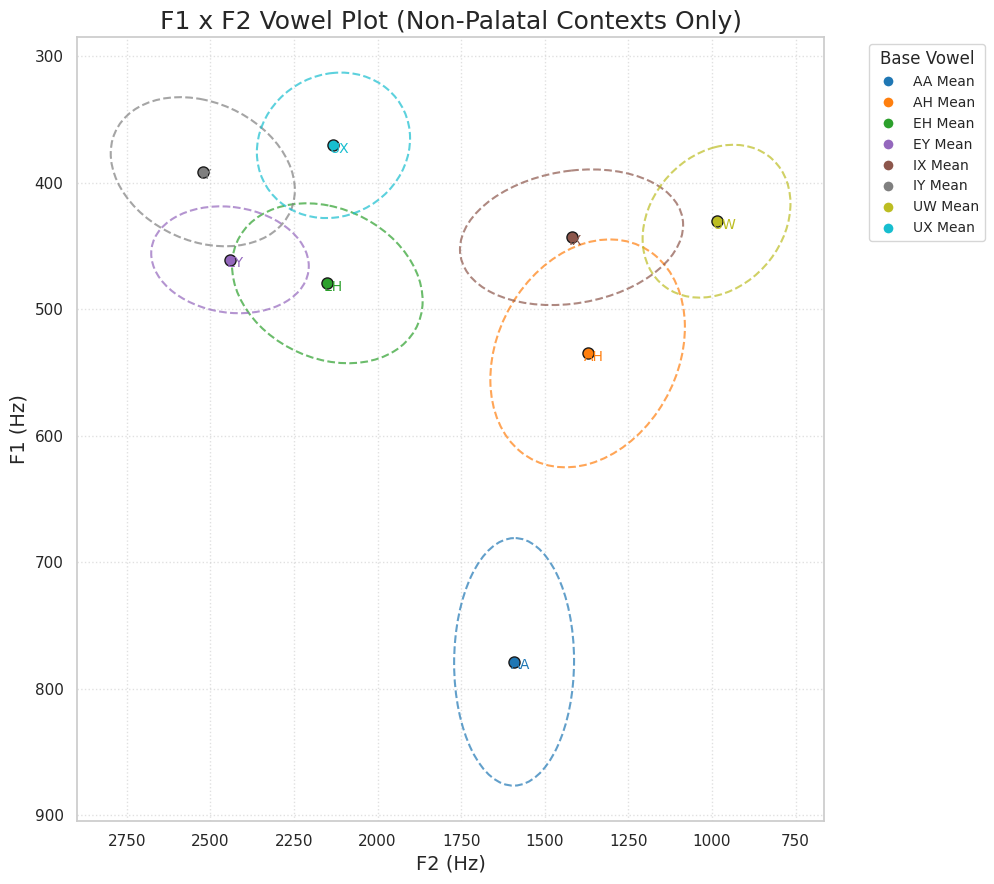

/tmp/ipython-input-3756041146.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors2 = cm.get_cmap('tab10', len(base_labels_sorted)) # Use same colormap for consistency


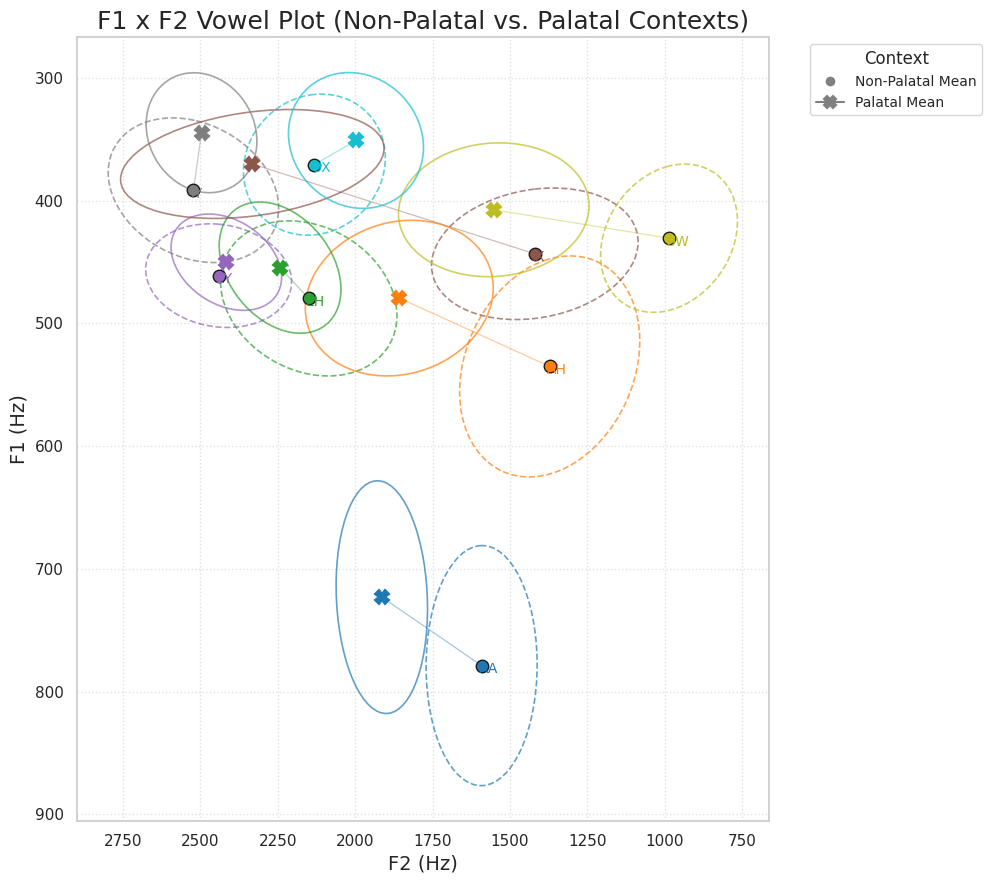

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm # For color mapping
import re # Regular expression library for stripping numbers

# --- New step: Create 'base_vowel' column ---
# This uses a regular expression to remove any trailing digits from the 'label'
filtered_df['base_vowel'] = filtered_df['label'].apply(lambda x: re.sub(r'[0-9]', '', x))

# --- Define palatal consonants and create 'is_palatal' flag ---
# The list of palatal consonants from your pre_seg values
palatal_tokens = ['jː', 'j', 'J', 'ɕ', 'ɕː', 'tʃ', 'ʃː', 'ts']
escaped_palatals = [re.escape(x) for x in palatal_tokens]

# Create a regex pattern to match any of the palatal tokens, handling them as whole units
# (?:...) is for non-capturing groups, | is for OR.
# This pattern checks for the token at word boundaries or includes the explicit palatalization mark 'ʲ'
pal_pattern = r'(?:^|\s)(?:' + '|'.join(escaped_palatals) + r')(?:$|\s)|ʲ'

filtered_df['is_palatal'] = filtered_df['pre_seg'].astype(str).str.contains(pal_pattern, regex=True)

print("Total vowel tokens:", len(filtered_df))
print("Tokens after palatal consonants:", filtered_df['is_palatal'].sum())
print("Tokens after non-palatal consonants:", (~filtered_df['is_palatal']).sum())
print("-" * 50)


# --- Helper function to compute means and covariances for a given DataFrame subset ---
def compute_vowel_stats(df_subset, min_data_for_cov=2):
    vowel_means = df_subset.groupby('base_vowel')[['F1', 'F2']].mean()
    vowel_covariances = {}
    for base_vowel_label in df_subset['base_vowel'].unique():
        subset_f1f2 = df_subset[df_subset['base_vowel'] == base_vowel_label][['F1', 'F2']]
        if len(subset_f1f2) >= min_data_for_cov:
            vowel_covariances[base_vowel_label] = np.cov(subset_f1f2['F1'], subset_f1f2['F2'])
        else:
            # print(f"Warning: Not enough data for '{base_vowel_label}' to calculate covariance matrix. Skipping ellipse.")
            vowel_covariances[base_vowel_label] = None
    return vowel_means, vowel_covariances

# --- Helper function to plot means and ellipses ---
def plot_vowel_formants(ax, vowel_means, vowel_covariances, base_labels, colors, title_suffix="", marker='o', markersize=8, markeredgewidth=1.0, markeredgecolor='k', markerfacecolor=None, linestyle='--', linewidth=1.5, alpha=0.7, annotate_labels=True, label_prefix="", connection_color=None):
    for i, base_vowel_label in enumerate(base_labels):
        if base_vowel_label not in vowel_means.index:
            continue # Skip if no data for this vowel in this subset

        mean_f1 = vowel_means.loc[base_vowel_label, 'F1']
        mean_f2 = vowel_means.loc[base_vowel_label, 'F2']
        color = colors(i) if colors is not None else 'k' # Use assigned color or black

        # Plot the mean point
        current_markerfacecolor = color if markerfacecolor is None else markerfacecolor
        ax.plot(mean_f2, mean_f1, marker, color=markeredgecolor, markerfacecolor=current_markerfacecolor,
                markersize=markersize, markeredgewidth=markeredgewidth, zorder=5)

        if annotate_labels:
            # Only annotate for the non-palatal plot or if explicitly requested in Plot B setup
            # This ensures labels don't clutter when plotting both palatal/non-palatal
            ax.text(mean_f2 + 10, mean_f1 + 6, base_vowel_label, color=color, fontsize=10, zorder=6)


        # Plot ellipse only if covariance matrix was successfully calculated
        cov_matrix = vowel_covariances.get(base_vowel_label)
        if cov_matrix is not None:
            # Calculate ellipse parameters from the covariance matrix
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

            # Sort eigenvalues in descending order and get corresponding eigenvectors
            order = eigenvalues.argsort()[::-1]
            eigenvalues = eigenvalues[order]
            eigenvectors = eigenvectors[:, order]

            # The angle of the ellipse is the angle of the eigenvector corresponding to the largest eigenvalue
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))

            # For a "1 standard deviation" ellipse, the half-axes are proportional to sqrt(eigenvalues).
            # Ensure non-negative eigenvalues for sqrt
            width, height = 2 * np.sqrt(np.clip(eigenvalues, a_min=0, a_max=None))

            # Create and add the ellipse patch
            ellipse = Ellipse((mean_f2, mean_f1), width=width, height=height,
                              angle=angle, facecolor='none', edgecolor=color,
                              linestyle=linestyle, linewidth=linewidth, alpha=alpha, zorder=3)
            ax.add_patch(ellipse)

    ax.set_title(f'F1 x F2 Vowel Plot {title_suffix}', fontsize=18)
    ax.set_xlabel('F2 (Hz)', fontsize=14)
    ax.set_ylabel('F1 (Hz)', fontsize=14)
    ax.invert_yaxis() # F1 is traditionally inverted in phonetic plots
    ax.invert_xaxis() # F2 is traditionally inverted in phonetic plots
    ax.grid(True, linestyle=':', alpha=0.6)


# --- Filter data for non-palatal contexts ---
non_palatal_df = filtered_df[~filtered_df['is_palatal']]
vowel_means_nonpal, vowel_covariances_nonpal = compute_vowel_stats(non_palatal_df)

# --- Plot 1: Vowel Means after Non-Palatal Consonants Only ---
fig1, ax1 = plt.subplots(figsize=(12, 9))
base_labels_sorted = sorted(filtered_df['base_vowel'].unique()) # For consistent coloring
colors1 = cm.get_cmap('tab10', len(base_labels_sorted))

plot_vowel_formants(ax1, vowel_means_nonpal, vowel_covariances_nonpal,
                    base_labels_sorted, colors1,
                    title_suffix="(Non-Palatal Contexts Only)")

ax1.legend([plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors1(i), markersize=8, label=f'{label} Mean')
            for i, label in enumerate(base_labels_sorted) if label in vowel_means_nonpal.index],
           [f'{label} Mean' for label in base_labels_sorted if label in vowel_means_nonpal.index],
           title='Base Vowel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# --- Plot 2: Vowel Means with Both Non-Palatal and Palatal Consonants ---
palatal_df = filtered_df[filtered_df['is_palatal']]
vowel_means_pal, vowel_covariances_pal = compute_vowel_stats(palatal_df)

fig2, ax2 = plt.subplots(figsize=(12, 9))
colors2 = cm.get_cmap('tab10', len(base_labels_sorted)) # Use same colormap for consistency

for i, base_vowel_label in enumerate(base_labels_sorted):
    color = colors2(i)

    # Plot Non-Palatal Mean (filled circle, dashed ellipse)
    if base_vowel_label in vowel_means_nonpal.index:
        mean_f1_nonpal = vowel_means_nonpal.loc[base_vowel_label, 'F1']
        mean_f2_nonpal = vowel_means_nonpal.loc[base_vowel_label, 'F2']
        ax2.plot(mean_f2_nonpal, mean_f1_nonpal, 'o', color='k', markerfacecolor=color,
                 markersize=9, markeredgewidth=1.0, zorder=5)

        cov_matrix_nonpal = vowel_covariances_nonpal.get(base_vowel_label)
        if cov_matrix_nonpal is not None:
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix_nonpal)
            order = eigenvalues.argsort()[::-1]
            eigenvalues = eigenvalues[order]
            eigenvectors = eigenvectors[:, order]
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))
            width, height = 2 * np.sqrt(np.clip(eigenvalues, a_min=0, a_max=None))
            ellipse = Ellipse((mean_f2_nonpal, mean_f1_nonpal), width=width, height=height,
                              angle=angle, facecolor='none', edgecolor=color,
                              linestyle='--', linewidth=1.2, alpha=0.7, zorder=3)
            ax2.add_patch(ellipse)

    # Plot Palatal Mean (X marker, solid ellipse)
    if base_vowel_label in vowel_means_pal.index:
        mean_f1_pal = vowel_means_pal.loc[base_vowel_label, 'F1']
        mean_f2_pal = vowel_means_pal.loc[base_vowel_label, 'F2']
        ax2.plot(mean_f2_pal, mean_f1_pal, 'X', color=color,
                 markersize=10, markeredgewidth=1.5, zorder=6)

        cov_matrix_pal = vowel_covariances_pal.get(base_vowel_label)
        if cov_matrix_pal is not None:
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix_pal)
            order = eigenvalues.argsort()[::-1]
            eigenvalues = eigenvalues[order]
            eigenvectors = eigenvectors[:, order]
            angle = np.degrees(np.arctan2(*eigenvectors[:, 0]))
            width, height = 2 * np.sqrt(np.clip(eigenvalues, a_min=0, a_max=None))
            ellipse = Ellipse((mean_f2_pal, mean_f1_pal), width=width, height=height,
                              angle=angle, facecolor='none', edgecolor=color,
                              linestyle='-', linewidth=1.2, alpha=0.7, zorder=4)
            ax2.add_patch(ellipse)

    # Connect non-palatal and palatal means with a line if both exist
    if (base_vowel_label in vowel_means_nonpal.index) and (base_vowel_label in vowel_means_pal.index):
        ax2.plot([mean_f2_nonpal, mean_f2_pal],
                 [mean_f1_nonpal, mean_f1_pal],
                 color=color, alpha=0.4, linewidth=0.9, zorder=2)

    # Add text labels for the vowel
    # You might prefer to label only one of the points, or not at all, to avoid clutter
    if base_vowel_label in vowel_means_nonpal.index:
        ax2.text(vowel_means_nonpal.loc[base_vowel_label, 'F2'] + 10,
                 vowel_means_nonpal.loc[base_vowel_label, 'F1'] + 6,
                 base_vowel_label, color=color, fontsize=10, zorder=7)
    elif base_vowel_label in vowel_means_pal.index:
        ax2.text(vowel_means_pal.loc[base_vowel_label, 'F2'] + 10,
                 vowel_means_pal.loc[base_vowel_label, 'F1'] + 6,
                 base_vowel_label, color=color, fontsize=10, zorder=7)


ax2.set_title('F1 x F2 Vowel Plot (Non-Palatal vs. Palatal Contexts)', fontsize=18)
ax2.set_xlabel('F2 (Hz)', fontsize=14)
ax2.set_ylabel('F1 (Hz)', fontsize=14)
ax2.invert_yaxis()
ax2.invert_xaxis()
ax2.grid(True, linestyle=':', alpha=0.6)

# Create a custom legend for marker types
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Non-Palatal Mean'),
    plt.Line2D([0], [0], marker='X', color='gray', markersize=8, markeredgewidth=1.5, label='Palatal Mean')
]
ax2.legend(handles=legend_elements, title='Context', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()